## Useful functions

You don't need to change these functions, and you don't have to necessarilty use them to complete your assignment.

In [1]:
from IPython.display import display
from IPython.display import Markdown

def report(string):
    display(Markdown(string))

class Table:
    def header(self, *fields):
        self.doc = "|"
        for field in fields:
            self.doc += f" {field} |"
        self.doc += "\n"
        self.doc += "|"
        for field in fields:
            self.doc += " --- |"
        self.doc += "\n"
        return self

    def __init__(self):
        self.doc = ""

    def row(self, *values):
        self.doc += "|"
        for value in values:
            self.doc += f" {value} |"
        self.doc += "\n"
        return self

    def report(self):
        report(self.doc)

def start_table():
    table = Table()
    table.header("Model", "Recall", "Precision", "F1 Score", "Correct", "Missed", "False Positives")
    return table


enable_debug = False

def debug(string):
    if (enable_debug):
        print(string)

def sinTransform(val, period) :
    return np.sin(2*np.pi*val/period)

def cosTransform(val, period) :
    return np.cos(2*np.pi*val/period)


def sin_cos_transform(columnName, dataFrame):
    period = dataFrame[columnName].nunique()
    dataFrame[columnName + '_sin'] = dataFrame[columnName].map(lambda val: sinTransform(val, period))
    dataFrame[columnName + '_cos'] = dataFrame[columnName].map(lambda val: cosTransform(val, period))

DEFAULT_COLUMNS_TO_DROP= ['day_of_year', 'season', 'season_encoded']
def dropColumns(dataframe, columns=DEFAULT_COLUMNS_TO_DROP):
    return dataframe.drop(columns=columns)

# https://xkcd.com/221/ - 4 is overused
random_seed = 221

In [2]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# plot one or more features (using separate plots) for a start and end date, if y is set then it shows the anomalies
#  (could be predicted or real if ground truth used)
def plot_features(df, start_day, start_year, end_day, end_year, features, y=None):
    # Filter the period
    mask = (
        (df['year'] > start_year) |
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) |
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    df_period = df_period.reset_index(drop=False)  # Keep original indices for mapping y
    df_period['date'] = pd.to_datetime(
        df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')

    if isinstance(features, str):
        features = [features]

    for feature in features:
        plt.figure(figsize=(10, 4))
        plt.plot(df_period['date'], df_period[feature], marker='o', linestyle='-')

        # If y is provided, plot anomalies
        if y is not None:
            anomaly_indices = df_period[df_period['index'].map(lambda idx: y[idx] == -1)].index
            plt.scatter(
                df_period.loc[anomaly_indices, 'date'],
                df_period.loc[anomaly_indices, feature],
                color='red', marker='x', s=100, label='Anomaly'
            )
            plt.legend()

        plt.title(f'{feature} over time')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# show a summary of the dataset, not crucial, but useful to understand the data
def print_summary(y_true):
    total = len(y_true)
    n_anomalies = (y_true == -1).sum()
    n_normals = (y_true == 1).sum()

    print("Dataset Summary:")
    print(f"Total instances:         {total}")
    print(f"Normal instances (1):    {n_normals}")
    print(f"Anomalous instances (-1): {n_anomalies}")
    print(f"Anomaly ratio:           {n_anomalies / total:.3%}")

# plot detections, useful when you already have the predictions and want to observe then on the data for each feature
def plot_detection(df, y_true, y_pred, start_day, start_year, end_day, end_year, feature):
    mask = (
        (df['year'] > start_year) |
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) |
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    idx_period = df_period.index
    df_period['date'] = pd.to_datetime(
    df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')
    y_true_period = y_true[idx_period]
    y_pred_period = y_pred[idx_period]

    correct = (y_true_period == -1) &  (y_pred_period == -1)
    missed = (y_true_period == -1) & (y_pred_period != -1)
    false_pos = (y_true_period != -1) & (y_pred_period == -1)

    plt.figure(figsize=(10, 4))
    plt.plot(df_period['date'], df_period[feature], label=feature, color='blue', linestyle='-')
    plt.scatter(df_period.loc[correct, 'date'], df_period.loc[correct, feature],
                marker='x', color='green', label='Correct Anomaly')
    plt.scatter(df_period.loc[missed, 'date'], df_period.loc[missed, feature],
                marker='x', color='red', label='Missed Anomaly')
    plt.scatter(df_period.loc[false_pos, 'date'], df_period.loc[false_pos, feature],
                marker='x', color='orange', label='False Positive')

    plt.title(f'{feature} with Detected Anomalies')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# to facilitate the visualization of the results for the anomaly detection methods in part 1
def evaluate_predictions(y_true, y_pred, model_name="unnamed", header=True, table=None):
    # convert from -1 to 1 (1 for anomaly, 0 for normal) for evaluating
    y_true_binary = (y_true == -1).astype(int)
    y_pred_binary = (y_pred == -1).astype(int)

    recall = recall_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary)
    f1score = f1_score(y_true_binary, y_pred_binary)

    correct = (y_true == -1) & (y_pred == -1)
    missed = (y_true == -1) & (y_pred != -1)
    false_positives = (y_true != -1) & (y_pred == -1)

    if header:
        table.header("Model", "Recall", "Precision", "F1 Score", "Correct", "Missed", "False Positives")
    table.row(model_name, f"{recall:.3f}", f"{precision:.3f}", f"{f1score:.3f}", correct.sum(), missed.sum(), false_positives.sum())

## Example: reading and visualizing the data

In [3]:
import os
import pandas as pd

# Loading the data. y2122 contains the 'labels'
df2122 = None
y2122 = None

# Check and load if files exist
if os.path.exists("GenSyn2122.csv") and os.path.exists("GenSyn_labels2122.csv"):
    print("Loading GenSyn2122 dataset...")
    df2122 = pd.read_csv("GenSyn2122.csv")
    # -1 = anomaly, 1 = normal
    y2122 = pd.read_csv("GenSyn_labels2122.csv")['anomaly_label'].values

# Visualise part of the data...
# plot_features(df2122, 1, 2021, 100, 2021, ['temperature','energy_usage', 'season'])
display(df2122)

Loading GenSyn2122 dataset...


,year,day_of_year,season,temperature,humidity,energy_usage
0,2021,1,summer,19.708638,78.625889,11.731837
1,2021,2,summer,20.703554,78.350411,13.453957
2,2021,3,summer,21.339178,82.736788,15.393096
3,2021,4,summer,20.823304,79.921728,16.657684
4,2021,5,summer,22.277698,80.406175,16.927320
...,...,...,...,...,...,...
725,2022,361,summer,24.648768,79.422802,18.579817
726,2022,362,summer,24.362897,80.541095,19.394421
727,2022,363,summer,24.730546,85.748327,20.060006
728,2022,364,summer,26.975549,81.506959,20.840548


### Example: Using function evaluate_predictions

In [4]:
# evaluate_predictions(y_true=y2122, y_pred=the predictions of your model, model_name="name of the model", header=True):
# for example, if we use the ground truth to evaluate. You can past the result on a markdown cell to get a nice looking table
iso_table = Table()
evaluate_predictions(y_true=y2122, y_pred=y2122, model_name="example", header=True, table=iso_table)

iso_table.report()

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| example | 1.000 | 1.000 | 1.000 | 18 | 0 | 0 |


### Example: plotting anomalies using plot_detection

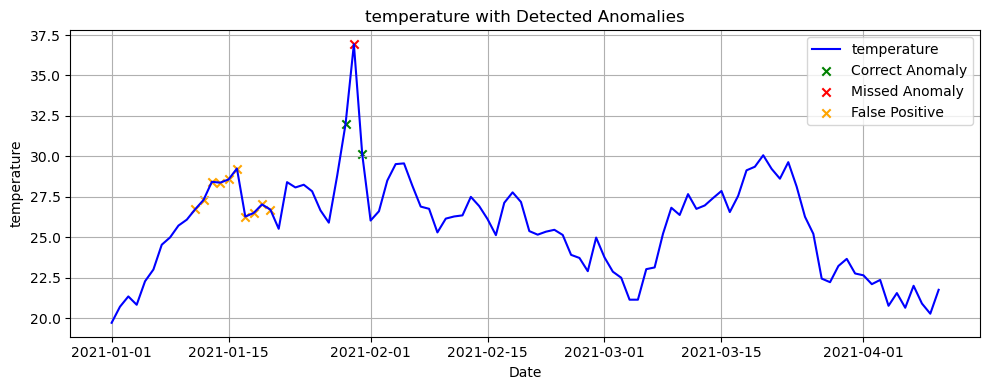

In [5]:
# generating some fake predictions for the plot
fake_preds=y2122.copy()
fake_preds[10:20] = -1
fake_preds[29] = 1
plot_detection(df=df2122, y_true=y2122, y_pred=fake_preds, start_day=1, start_year=2021, end_day=100, end_year=2021, feature="temperature")

### Example: using function plot_features

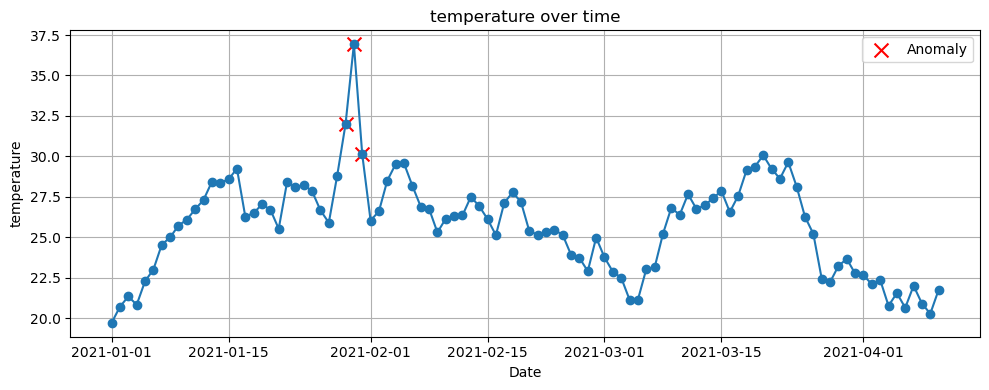

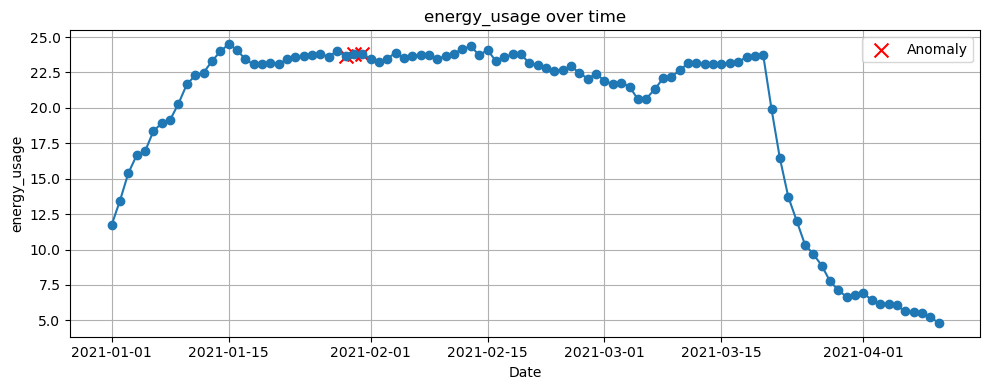

In [6]:
plot_features(df=df2122, y=y2122, start_day=1, start_year=2021, end_day=100, end_year=2021, features=["temperature", "energy_usage"])

### Statistics about the anomalies

In [7]:
print_summary(y2122)

Dataset Summary:
Total instances:         730
Normal instances (1):    712
Anomalous instances (-1): 18
Anomaly ratio:           2.466%


# Part 1: Anomaly detection
## <span style="color: red; font-weight: 700;">Your answers should start here!</span>

Use the provided functions to help you, if you want to code your own plotting functions, feel free to do so, but make sure the metrics calculation is correct!

### a) Data Transformation

In [8]:
import numpy as np

df2122Transformed = df2122.copy()

# 2: Sin/Cos mapping for day_of_year
# The sin, cos transform maps the periodic value to a unit circle, mod(max(column) + 1) - assuming the column is zero-numbered.
# this is because sin(0) == sin(2*pi)
sin_cos_transform(dataFrame=df2122Transformed, columnName='day_of_year')


# 1: Map season to integer
season_mapping = {'summer' : 0, 'autumn': 1, 'winter': 2, 'spring': 3}
df2122Transformed['season_encoded'] = df2122Transformed['season'].map(season_mapping)
sin_cos_transform(dataFrame=df2122Transformed, columnName='season_encoded')

df2122Transformed

,year,day_of_year,season,temperature,humidity,energy_usage,day_of_year_sin,day_of_year_cos,season_encoded,season_encoded_sin,season_encoded_cos
0,2021,1,summer,19.708638,78.625889,11.731837,1.721336e-02,0.999852,0,0.0,1.0
1,2021,2,summer,20.703554,78.350411,13.453957,3.442161e-02,0.999407,0,0.0,1.0
2,2021,3,summer,21.339178,82.736788,15.393096,5.161967e-02,0.998667,0,0.0,1.0
3,2021,4,summer,20.823304,79.921728,16.657684,6.880243e-02,0.997630,0,0.0,1.0
4,2021,5,summer,22.277698,80.406175,16.927320,8.596480e-02,0.996298,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
725,2022,361,summer,24.648768,79.422802,18.579817,-6.880243e-02,0.997630,0,0.0,1.0
726,2022,362,summer,24.362897,80.541095,19.394421,-5.161967e-02,0.998667,0,0.0,1.0
727,2022,363,summer,24.730546,85.748327,20.060006,-3.442161e-02,0.999407,0,0.0,1.0
728,2022,364,summer,26.975549,81.506959,20.840548,-1.721336e-02,0.999852,0,0.0,1.0


## b) Isolation Forest and LOF

### Isolation Forest

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| isolation forest | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |


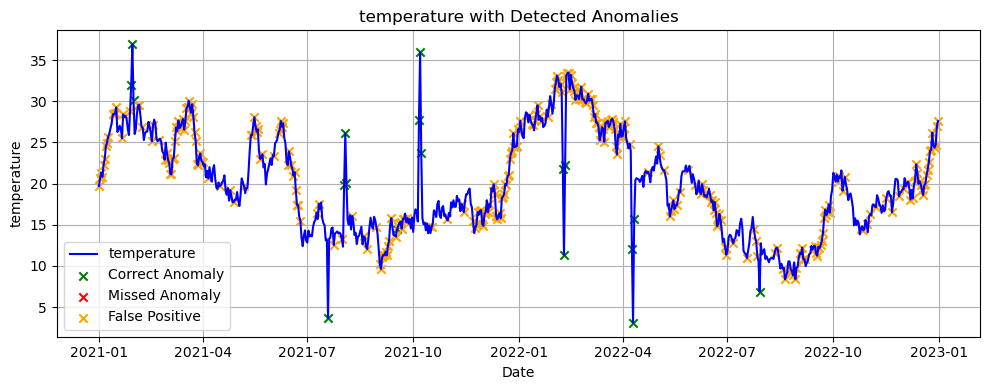

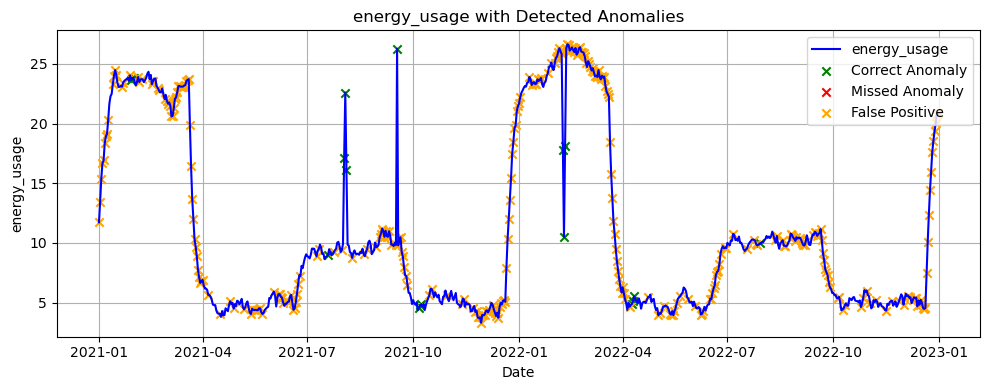

In [9]:
from sklearn.ensemble import IsolationForest

dfiso = dropColumns(df2122Transformed)


isolation_forest = IsolationForest(random_state=random_seed)
isolation_forest.fit(dfiso)
if_labels = isolation_forest.predict(dfiso)

if_table = Table()
evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name="isolation forest", header=True, table=if_table)
if_table.report()

plot_detection(df=df2122, y_true=y2122, y_pred=if_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")

plot_detection(df=df2122, y_true=y2122, y_pred=if_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")



### LOF - Local Outlier Factor

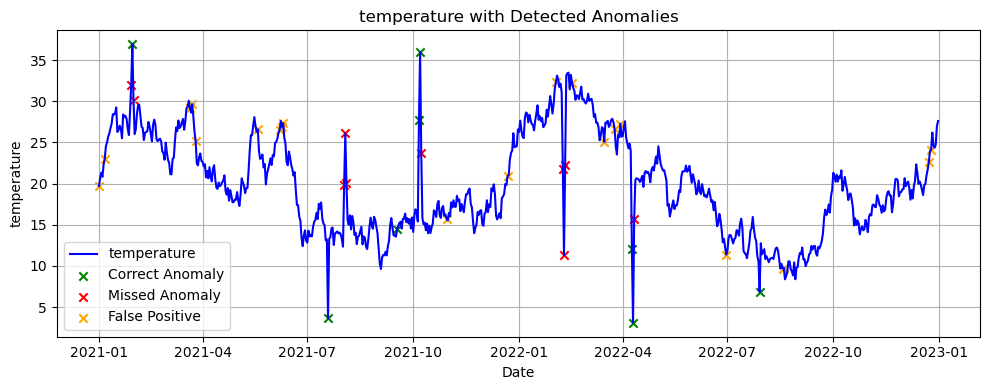

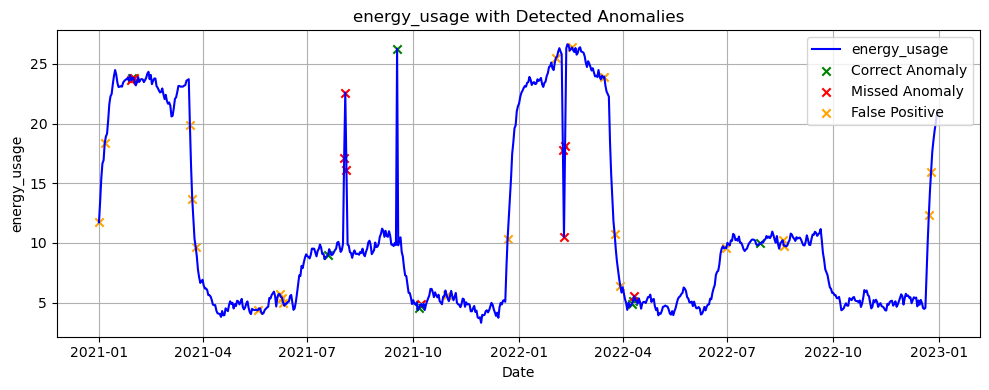

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| local outlier factor | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |


In [10]:
from sklearn.neighbors import LocalOutlierFactor

dflof = dropColumns(df2122Transformed)
local_outlier_factor = LocalOutlierFactor()
lof_labels = local_outlier_factor.fit_predict(dflof)


plot_detection(df=df2122, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df2122, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")

lof_table = Table()
evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name="local outlier factor", header=True, table=lof_table)

lof_table.report()

### Answers

#### Which model had higher recall? Which had higher precision?

Isolation Forest had higher recall, Local Outlier Factor had higher precision. However, Isolation Forest had high recall because it had terrible precision, recording 190 false positives.

#### What do these differences suggest about how each algorithm works?

Isolation Forest is trying to determine if a value is separable from its peers by measuring how deep into a decision tree the values are bucketed. Local Outlier Factor is measuring how similar values are in the region around a point.

Local Outlier Factor is comparing a measurement with other nearby values, allowing it to detect the anomalies where the data changes rapidly.

#### In which situations would one be preferred over the other?

Isolation Forest will work best when there is a large number of values, and multiple examples for each range. For example, "year", with only two values ensures all trees using that feature are shallow - hindering the performance. Additionally, since it is (by default) considering a single feature per tree, it cannot detect problems where a values range varies with another value - it will only find globally extreme values.

Local Outlier Factor will work best when the distances between elements is Euclidean. If distance in some dimensions is different to others, then normal variation in that dimension may overwhelm the anomalous value. It is possible for LOF to "boil the frog", where the value changes over time slow enough that they aren't anomalies.

## c) Hyperparameter tuning

Looking at the original data, there are 730 rows. From a visual inspection of the graphs, I see 17 anomalies. The test data shows 18, but I'm going to pretend to not have that data.

Therefore, contamination = 17/230 = 0.0739.

### Isolation Forest

In [51]:
from sklearn.ensemble import IsolationForest

def isoTableHyperParameterStep1(dataframe, bootstrap=False):
    iso_table = start_table()
    for contamination in (0.01, 0.03, 0.05, 0.0739, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 'auto') :
        isolation_forest = IsolationForest(
            random_state=random_seed,
            contamination=contamination,
            bootstrap=bootstrap)
        if_labels = isolation_forest.fit_predict(dfiso)
        evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"c={contamination}", header=False, table=iso_table)
    iso_table.report()

    iso_table = start_table()
    for n_estimators in (5, 10, 30, 50, 100, 200, 300, 400, 500) :
        isolation_forest = IsolationForest(
            random_state=random_seed,
            n_estimators=n_estimators,
            bootstrap=bootstrap)
        if_labels = isolation_forest.fit_predict(dfiso)
        evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"n={n_estimators}", header=False, table=iso_table)
    iso_table.report()

def isoTableHyperParameterStep2(dataframe, contamination_list,
                                n_neighbours_list, bootstrap=False):
    iso_table = start_table()
    for contamination in contamination_list:
        for n_estimators in n_neighbours_list:
            isolation_forest = IsolationForest(
                random_state=random_seed,
                n_estimators=n_estimators,
                contamination=contamination,
                bootstrap=bootstrap)
            if_labels = isolation_forest.fit_predict(dataframe)
            evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"({contamination}, {n_estimators})",
                                 header=False, table=iso_table)
    iso_table.report()

def isoTableHyperParameterForPublication(dataframe,
                                         contamination_list,
                                         n_estimators_list, bootstrap=False):
    for contamination in contamination_list:
        iso_table = start_table()
        for n_estimators in n_estimators_list:
            isolation_forest = IsolationForest(
                random_state=random_seed,
                n_estimators=n_estimators,
                contamination=contamination,
                bootstrap=bootstrap)
            if_labels = isolation_forest.fit_predict(dataframe)
            evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"({contamination}, {n_estimators})",
                                 header=False, table=iso_table)
        iso_table.report()
        report(f"*Table for IsolationForest (contamination = {contamination})*")


In [12]:
# Dropping the additional columns had _minimal_ effect until it got to "auto". It caused problems once we started tuning.
dfiso = dropColumns(df2122Transformed)

isoTableHyperParameterStep1(dfiso)

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.167 | 0.375 | 0.231 | 3 | 15 | 5 |
| c=0.03 | 0.222 | 0.182 | 0.200 | 4 | 14 | 18 |
| c=0.05 | 0.333 | 0.162 | 0.218 | 6 | 12 | 31 |
| c=0.0739 | 0.389 | 0.130 | 0.194 | 7 | 11 | 47 |
| c=0.08 | 0.500 | 0.153 | 0.234 | 9 | 9 | 50 |
| c=0.1 | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| c=0.15 | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| c=0.2 | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| c=0.25 | 0.722 | 0.071 | 0.129 | 13 | 5 | 170 |
| c=0.3 | 0.778 | 0.064 | 0.118 | 14 | 4 | 205 |
| c=0.35 | 0.944 | 0.066 | 0.124 | 17 | 1 | 239 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=5 | 1.000 | 0.042 | 0.080 | 18 | 0 | 412 |
| n=10 | 0.944 | 0.043 | 0.082 | 17 | 1 | 382 |
| n=30 | 0.944 | 0.053 | 0.100 | 17 | 1 | 305 |
| n=50 | 1.000 | 0.050 | 0.096 | 18 | 0 | 339 |
| n=100 | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |
| n=200 | 1.000 | 0.052 | 0.098 | 18 | 0 | 330 |
| n=300 | 1.000 | 0.053 | 0.101 | 18 | 0 | 321 |
| n=400 | 1.000 | 0.051 | 0.097 | 18 | 0 | 335 |
| n=500 | 1.000 | 0.050 | 0.095 | 18 | 0 | 341 |


In [13]:
dfiso = dropColumns(df2122Transformed)

isoTableHyperParameterStep2(
    dataframe=dfiso,
    contamination_list=(0.01, 0.03, 0.05, 0.07, 0.0739, 0.08, 0.09, 0.1, 0.15, 0.2, 'auto'),
    n_neighbours_list=(5, 10, 30, 50, 100, 200, 300, 400, 500))


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.01, 5) | 0.000 | 0.000 | 0.000 | 0 | 18 | 8 |
| (0.01, 10) | 0.056 | 0.125 | 0.077 | 1 | 17 | 7 |
| (0.01, 30) | 0.056 | 0.125 | 0.077 | 1 | 17 | 7 |
| (0.01, 50) | 0.167 | 0.375 | 0.231 | 3 | 15 | 5 |
| (0.01, 100) | 0.167 | 0.375 | 0.231 | 3 | 15 | 5 |
| (0.01, 200) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 300) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 400) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 500) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.03, 5) | 0.111 | 0.091 | 0.100 | 2 | 16 | 20 |
| (0.03, 10) | 0.111 | 0.091 | 0.100 | 2 | 16 | 20 |
| (0.03, 30) | 0.222 | 0.182 | 0.200 | 4 | 14 | 18 |
| (0.03, 50) | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| (0.03, 100) | 0.222 | 0.182 | 0.200 | 4 | 14 | 18 |
| (0.03, 200) | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| (0.03, 300) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 400) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 500) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.05, 5) | 0.278 | 0.135 | 0.182 | 5 | 13 | 32 |
| (0.05, 10) | 0.222 | 0.108 | 0.145 | 4 | 14 | 33 |
| (0.05, 30) | 0.333 | 0.162 | 0.218 | 6 | 12 | 31 |
| (0.05, 50) | 0.278 | 0.135 | 0.182 | 5 | 13 | 32 |
| (0.05, 100) | 0.333 | 0.162 | 0.218 | 6 | 12 | 31 |
| (0.05, 200) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 300) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 400) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 500) | 0.444 | 0.216 | 0.291 | 8 | 10 | 29 |
| (0.07, 5) | 0.389 | 0.137 | 0.203 | 7 | 11 | 44 |
| (0.07, 10) | 0.222 | 0.077 | 0.114 | 4 | 14 | 48 |
| (0.07, 30) | 0.333 | 0.115 | 0.171 | 6 | 12 | 46 |
| (0.07, 50) | 0.333 | 0.115 | 0.171 | 6 | 12 | 46 |
| (0.07, 100) | 0.389 | 0.135 | 0.200 | 7 | 11 | 45 |
| (0.07, 200) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 300) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 400) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.07, 500) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.0739, 5) | 0.389 | 0.132 | 0.197 | 7 | 11 | 46 |
| (0.0739, 10) | 0.222 | 0.074 | 0.111 | 4 | 14 | 50 |
| (0.0739, 30) | 0.333 | 0.111 | 0.167 | 6 | 12 | 48 |
| (0.0739, 50) | 0.333 | 0.111 | 0.167 | 6 | 12 | 48 |
| (0.0739, 100) | 0.389 | 0.130 | 0.194 | 7 | 11 | 47 |
| (0.0739, 200) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 300) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 400) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739, 500) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.08, 5) | 0.444 | 0.140 | 0.213 | 8 | 10 | 49 |
| (0.08, 10) | 0.222 | 0.068 | 0.104 | 4 | 14 | 55 |
| (0.08, 30) | 0.333 | 0.102 | 0.156 | 6 | 12 | 53 |
| (0.08, 50) | 0.389 | 0.119 | 0.182 | 7 | 11 | 52 |
| (0.08, 100) | 0.500 | 0.153 | 0.234 | 9 | 9 | 50 |
| (0.08, 200) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 300) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 400) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.08, 500) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.09, 5) | 0.556 | 0.152 | 0.238 | 10 | 8 | 56 |
| (0.09, 10) | 0.222 | 0.061 | 0.095 | 4 | 14 | 62 |
| (0.09, 30) | 0.333 | 0.091 | 0.143 | 6 | 12 | 60 |
| (0.09, 50) | 0.444 | 0.121 | 0.190 | 8 | 10 | 58 |
| (0.09, 100) | 0.556 | 0.152 | 0.238 | 10 | 8 | 56 |
| (0.09, 200) | 0.611 | 0.167 | 0.262 | 11 | 7 | 55 |
| (0.09, 300) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.09, 400) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.09, 500) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.1, 5) | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| (0.1, 10) | 0.222 | 0.055 | 0.088 | 4 | 14 | 69 |
| (0.1, 30) | 0.444 | 0.110 | 0.176 | 8 | 10 | 65 |
| (0.1, 50) | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| (0.1, 100) | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| (0.1, 200) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 300) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 400) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 500) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.15, 5) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 10) | 0.444 | 0.073 | 0.125 | 8 | 10 | 102 |
| (0.15, 30) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 50) | 0.722 | 0.118 | 0.203 | 13 | 5 | 97 |
| (0.15, 100) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 200) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 300) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 400) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 500) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.2, 5) | 0.722 | 0.089 | 0.159 | 13 | 5 | 133 |
| (0.2, 10) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 30) | 0.778 | 0.096 | 0.171 | 14 | 4 | 132 |
| (0.2, 50) | 0.722 | 0.089 | 0.159 | 13 | 5 | 133 |
| (0.2, 100) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 200) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 300) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 400) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 500) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (auto, 5) | 1.000 | 0.042 | 0.080 | 18 | 0 | 412 |
| (auto, 10) | 0.944 | 0.043 | 0.082 | 17 | 1 | 382 |
| (auto, 30) | 0.944 | 0.053 | 0.100 | 17 | 1 | 305 |
| (auto, 50) | 1.000 | 0.050 | 0.096 | 18 | 0 | 339 |
| (auto, 100) | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |
| (auto, 200) | 1.000 | 0.052 | 0.098 | 18 | 0 | 330 |
| (auto, 300) | 1.000 | 0.053 | 0.101 | 18 | 0 | 321 |
| (auto, 400) | 1.000 | 0.051 | 0.097 | 18 | 0 | 335 |
| (auto, 500) | 1.000 | 0.050 | 0.095 | 18 | 0 | 341 |


In [14]:
dfiso = dropColumns(df2122Transformed)


isoTableHyperParameterForPublication(dataframe=dfiso,
                                         contamination_list=(0.07, 0.0739),
                                         n_estimators_list=(10, 50, 100, 200, 300, 400, 500))

report("**Post Search Hyperparameters**")
contamination = 0.07
n_estimators = 400
report(f"**contamination={contamination}, n_estimators={n_estimators}**")

iso_table = start_table()
isolation_forest = IsolationForest(random_state=random_seed, contamination=contamination, n_estimators=n_estimators)
if_labels = isolation_forest.fit_predict(dfiso)
evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"({contamination}, {n_estimators})", header=False, table=iso_table)

iso_table.report()


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.07, 10) | 0.222 | 0.077 | 0.114 | 4 | 14 | 48 |
| (0.07, 50) | 0.333 | 0.115 | 0.171 | 6 | 12 | 46 |
| (0.07, 100) | 0.389 | 0.135 | 0.200 | 7 | 11 | 45 |
| (0.07, 200) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 300) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 400) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.07, 500) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |


*Table for IsolationForest (contamination = 0.07)*

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.0739, 10) | 0.222 | 0.074 | 0.111 | 4 | 14 | 50 |
| (0.0739, 50) | 0.333 | 0.111 | 0.167 | 6 | 12 | 48 |
| (0.0739, 100) | 0.389 | 0.130 | 0.194 | 7 | 11 | 47 |
| (0.0739, 200) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 300) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 400) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739, 500) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |


*Table for IsolationForest (contamination = 0.0739)*

**Post Search Hyperparameters**

**contamination=0.07, n_estimators=400**

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.07, 400) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |


### Local Outlier Factor

In [15]:
def lofHyperParameterStep1(dataframe):
    # Noticed that auto works best, and it sets an offset of -1.5. Reverse engineer that to a percentage ends up around 0.035.
    # default n_neighbours is 20. However, that's too many based on the data.
    lof_table = start_table()
    for contamination in (0.01, 0.03, 0.035, 0.04, 0.045, 0.05, 0.0739, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 'auto'):
        local_outlier_factor = LocalOutlierFactor(contamination=contamination)
        lof_labels = local_outlier_factor.fit_predict(dataframe)
        evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"c={contamination}", header=False, table=lof_table)
    lof_table.report()

    lof_table = start_table()
    for n_neighbours in (2, 3, 4, 5, 6, 7, 10, 20, 30, 40, 50, 60, 70):
        local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours)
        lof_labels = local_outlier_factor.fit_predict(dataframe)
        evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"n={n_neighbours}", header=False, table=lof_table)
    lof_table.report()

def lofHyperParameterStep2(dataframe, contamination_list, n_neighbours_list):
    lof_table = start_table()
    for contamination in contamination_list:
        for n_neighbours in n_neighbours_list:
            local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours, contamination=contamination)
            lof_labels = local_outlier_factor.fit_predict(dflof)
            evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"({contamination},{n_neighbours})", header=False, table=lof_table)
    lof_table.report()

def lofHyperParameterForPublication(dataframe, contamination_list, n_neighbours_list):
    for contamination in contamination_list:
        lof_table = start_table()
        for n_neighbours in n_neighbours_list:
            local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours, contamination=contamination)
            lof_labels = local_outlier_factor.fit_predict(dataframe)
            evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"({contamination},{n_neighbours})", header=False, table=lof_table)
        lof_table.report()
        report(f"*Table for LocalOutlierFactor (contamination = {contamination})*")

In [16]:
from sklearn.neighbors import LocalOutlierFactor

dflof = dropColumns(df2122Transformed)

lofHyperParameterStep1(dflof)

lofHyperParameterStep2(
    dataframe=dflof,
    contamination_list=(0.01, 0.03, 0.035, 0.04, 0.045, 0.05, 0.0739, 'auto'),
    n_neighbours_list=(2, 3, 4, 5, 6, 7, 10, 20))

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| c=0.03 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| c=0.035 | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |
| c=0.04 | 0.444 | 0.267 | 0.333 | 8 | 10 | 22 |
| c=0.045 | 0.444 | 0.242 | 0.314 | 8 | 10 | 25 |
| c=0.05 | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| c=0.0739 | 0.500 | 0.167 | 0.250 | 9 | 9 | 45 |
| c=0.08 | 0.500 | 0.153 | 0.234 | 9 | 9 | 50 |
| c=0.1 | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| c=0.15 | 0.611 | 0.100 | 0.172 | 11 | 7 | 99 |
| c=0.2 | 0.778 | 0.096 | 0.171 | 14 | 4 | 132 |
| c=0.25 | 0.889 | 0.087 | 0.159 | 16 | 2 | 167 |
| c=0.3 | 1.000 | 0.082 | 0.152 | 18 | 0 | 201 |
| c=0.35 | 1.000 | 0.070 | 0.131 | 18 | 0 | 238 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=2 | 0.611 | 0.193 | 0.293 | 11 | 7 | 46 |
| n=3 | 0.500 | 0.250 | 0.333 | 9 | 9 | 27 |
| n=4 | 0.556 | 0.370 | 0.444 | 10 | 8 | 17 |
| n=5 | 0.556 | 0.345 | 0.426 | 10 | 8 | 19 |
| n=6 | 0.556 | 0.370 | 0.444 | 10 | 8 | 17 |
| n=7 | 0.556 | 0.345 | 0.426 | 10 | 8 | 19 |
| n=10 | 0.500 | 0.290 | 0.367 | 9 | 9 | 22 |
| n=20 | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |
| n=30 | 0.389 | 0.269 | 0.318 | 7 | 11 | 19 |
| n=40 | 0.444 | 0.286 | 0.348 | 8 | 10 | 20 |
| n=50 | 0.444 | 0.296 | 0.356 | 8 | 10 | 19 |
| n=60 | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |
| n=70 | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.01,2) | 0.333 | 0.750 | 0.462 | 6 | 12 | 2 |
| (0.01,3) | 0.333 | 0.750 | 0.462 | 6 | 12 | 2 |
| (0.01,4) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01,5) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01,6) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01,7) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01,10) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01,20) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.03,2) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03,3) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03,4) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03,5) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03,6) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03,7) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03,10) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03,20) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.035,2) | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |
| (0.035,3) | 0.500 | 0.346 | 0.409 | 9 | 9 | 17 |
| (0.035,4) | 0.500 | 0.346 | 0.409 | 9 | 9 | 17 |
| (0.035,5) | 0.500 | 0.346 | 0.409 | 9 | 9 | 17 |
| (0.035,6) | 0.556 | 0.385 | 0.455 | 10 | 8 | 16 |
| (0.035,7) | 0.556 | 0.385 | 0.455 | 10 | 8 | 16 |
| (0.035,10) | 0.500 | 0.346 | 0.409 | 9 | 9 | 17 |
| (0.035,20) | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |
| (0.04,2) | 0.444 | 0.267 | 0.333 | 8 | 10 | 22 |
| (0.04,3) | 0.500 | 0.300 | 0.375 | 9 | 9 | 21 |
| (0.04,4) | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| (0.04,5) | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| (0.04,6) | 0.611 | 0.367 | 0.458 | 11 | 7 | 19 |
| (0.04,7) | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| (0.04,10) | 0.500 | 0.300 | 0.375 | 9 | 9 | 21 |
| (0.04,20) | 0.444 | 0.267 | 0.333 | 8 | 10 | 22 |
| (0.045,2) | 0.500 | 0.273 | 0.353 | 9 | 9 | 24 |
| (0.045,3) | 0.500 | 0.273 | 0.353 | 9 | 9 | 24 |
| (0.045,4) | 0.556 | 0.303 | 0.392 | 10 | 8 | 23 |
| (0.045,5) | 0.611 | 0.333 | 0.431 | 11 | 7 | 22 |
| (0.045,6) | 0.611 | 0.333 | 0.431 | 11 | 7 | 22 |
| (0.045,7) | 0.556 | 0.303 | 0.392 | 10 | 8 | 23 |
| (0.045,10) | 0.500 | 0.273 | 0.353 | 9 | 9 | 24 |
| (0.045,20) | 0.444 | 0.242 | 0.314 | 8 | 10 | 25 |
| (0.05,2) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05,3) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05,4) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05,5) | 0.611 | 0.297 | 0.400 | 11 | 7 | 26 |
| (0.05,6) | 0.611 | 0.297 | 0.400 | 11 | 7 | 26 |
| (0.05,7) | 0.611 | 0.297 | 0.400 | 11 | 7 | 26 |
| (0.05,10) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05,20) | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| (0.0739,2) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739,3) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739,4) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739,5) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739,6) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739,7) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739,10) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739,20) | 0.500 | 0.167 | 0.250 | 9 | 9 | 45 |
| (auto,2) | 0.611 | 0.193 | 0.293 | 11 | 7 | 46 |
| (auto,3) | 0.500 | 0.250 | 0.333 | 9 | 9 | 27 |
| (auto,4) | 0.556 | 0.370 | 0.444 | 10 | 8 | 17 |
| (auto,5) | 0.556 | 0.345 | 0.426 | 10 | 8 | 19 |
| (auto,6) | 0.556 | 0.370 | 0.444 | 10 | 8 | 17 |
| (auto,7) | 0.556 | 0.345 | 0.426 | 10 | 8 | 19 |
| (auto,10) | 0.500 | 0.290 | 0.367 | 9 | 9 | 22 |
| (auto,20) | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |


In [17]:
dflof = dropColumns(df2122Transformed)

lofHyperParameterForPublication(dataframe=dflof, contamination_list=(0.035, 0.04, 0.045), n_neighbours_list=(4, 5, 6, 7, 20))

report("**Post Search Hyperparameters**")
contamination = 0.04
n_neighbours = 6
report(f"**contamination={contamination}, n_neighbours={n_neighbours}**")

lof_table = start_table()
local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours, contamination=contamination)
lof_labels = local_outlier_factor.fit_predict(dflof)
evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"({contamination},{n_neighbours})", header=False, table=lof_table)
lof_table.report()


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.035,4) | 0.500 | 0.346 | 0.409 | 9 | 9 | 17 |
| (0.035,5) | 0.500 | 0.346 | 0.409 | 9 | 9 | 17 |
| (0.035,6) | 0.556 | 0.385 | 0.455 | 10 | 8 | 16 |
| (0.035,7) | 0.556 | 0.385 | 0.455 | 10 | 8 | 16 |
| (0.035,20) | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |


*Table for LocalOutlierFactor (contamination = 0.035)*

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.04,4) | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| (0.04,5) | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| (0.04,6) | 0.611 | 0.367 | 0.458 | 11 | 7 | 19 |
| (0.04,7) | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| (0.04,20) | 0.444 | 0.267 | 0.333 | 8 | 10 | 22 |


*Table for LocalOutlierFactor (contamination = 0.04)*

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.045,4) | 0.556 | 0.303 | 0.392 | 10 | 8 | 23 |
| (0.045,5) | 0.611 | 0.333 | 0.431 | 11 | 7 | 22 |
| (0.045,6) | 0.611 | 0.333 | 0.431 | 11 | 7 | 22 |
| (0.045,7) | 0.556 | 0.303 | 0.392 | 10 | 8 | 23 |
| (0.045,20) | 0.444 | 0.242 | 0.314 | 8 | 10 | 25 |


*Table for LocalOutlierFactor (contamination = 0.045)*

**Post Search Hyperparameters**

**contamination=0.04, n_neighbours=6**

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.04,6) | 0.611 | 0.367 | 0.458 | 11 | 7 | 19 |


## d) Model Selection and Analysis

### Model Selection: Local Outlier Factor {contamination = 0.04, n_neighbors = 6}

The model which is appropriate depends on the goal for the model. In particular, it is the cost of a handling an alert, vs the cost of missing an anomaly. If the cost of the anomaly is high, then it may be acceptable to have a low precision, as long as recall is high.

Specifically:

```
let d = cost of a missed anomaly
let p = cost of processing an alert
let a = number of anomalies
let fp = number of false positives
let tp = number of true positives
let fn = number of missed anomalies

d * fn + p * (fp+tp) <= d * (fn + tp)
```

as long as the lhs is less than the rhs, the model has an operating cost benefit.

if a human is involved in the process, ["Normalisation of Deviance"](https://en.wikipedia.org/wiki/Normalization_of_deviance) needs to be considered. If there is low precision, a human will quickly start to ignore alerts, eventually disabling them. If the model feeds into another automated system which performs more expensive analysis, then more false positives can be allowed increasing recall.

Assuming "human in the loop", Local Outlier Factor model works better than Isolation Forest for most values. This would make sense, since time series should be closer to each other in most dimensions.

I aimed for a balance between precision and recall, through the F1 score. I selected Local Outlier Factor with contamination = 0.04 and n_neighbors = 6. I searched for values that found at least half of the anomalies, while avoiding the human being able to reliably ignore the alert.


### Analysis



### Why is the model so bad?

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.04,6) | 0.611 | 0.367 | 0.458 | 11 | 7 | 19 |


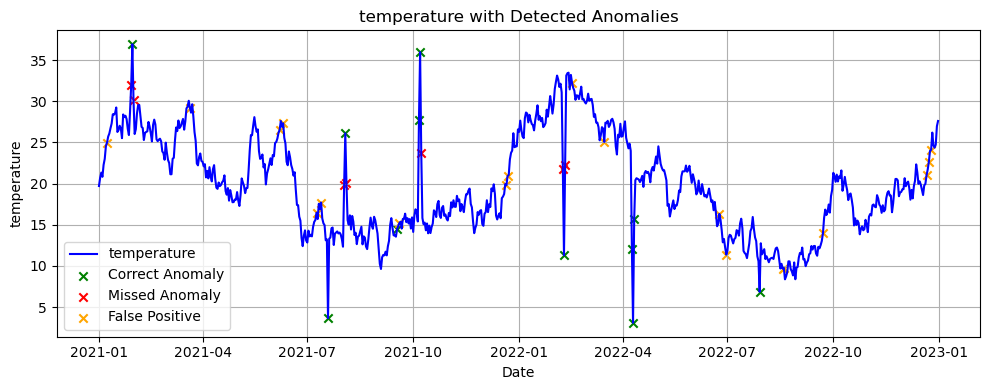

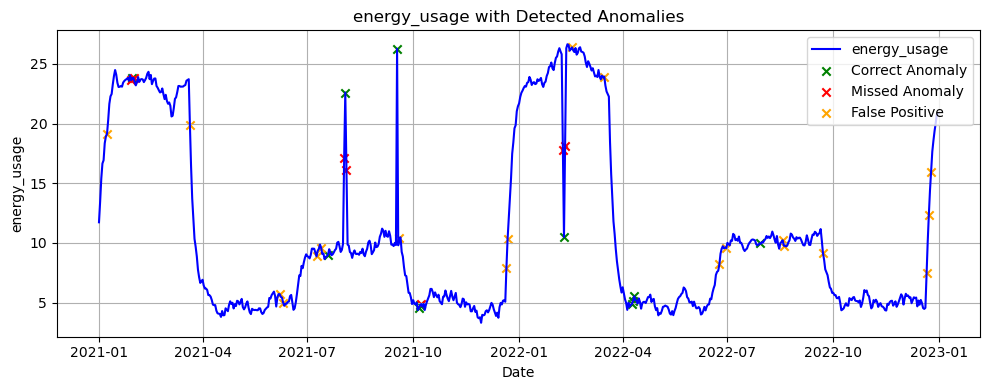

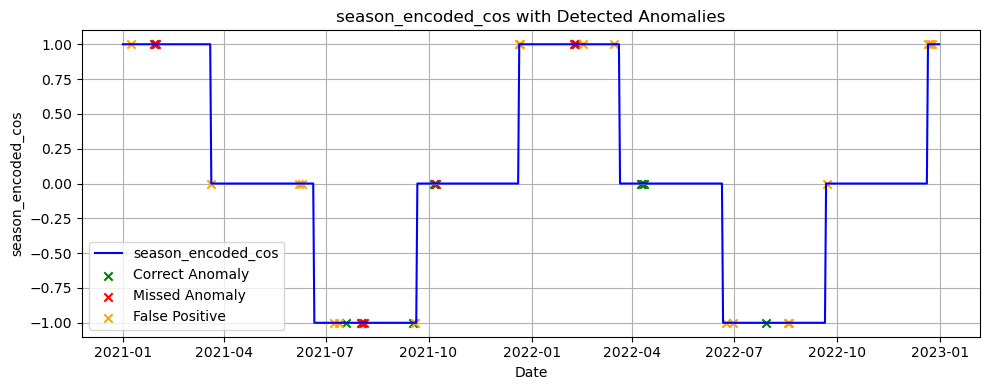

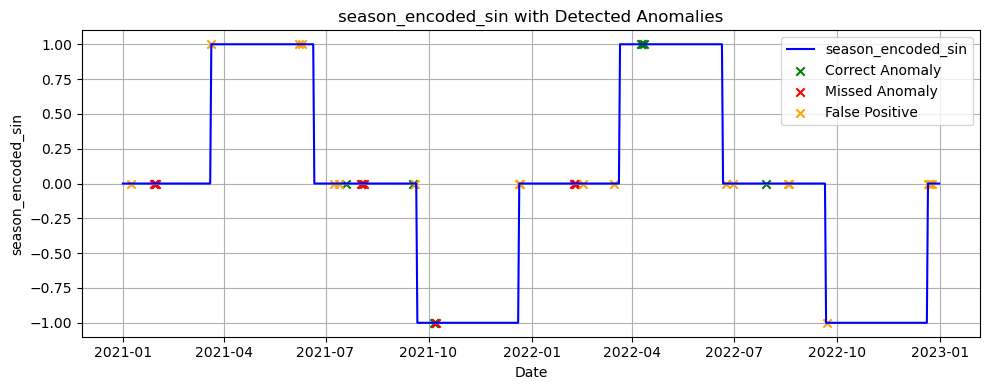

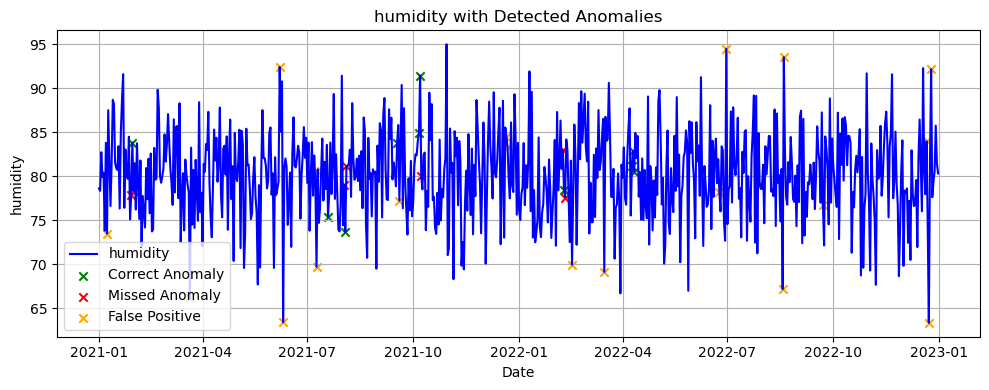

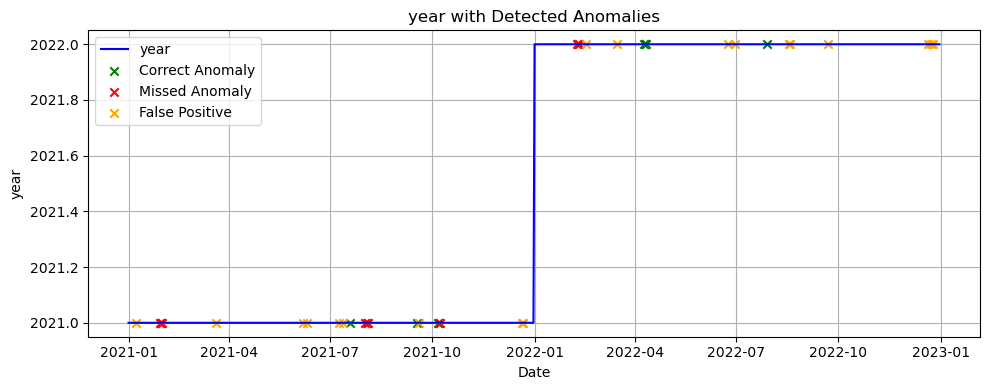

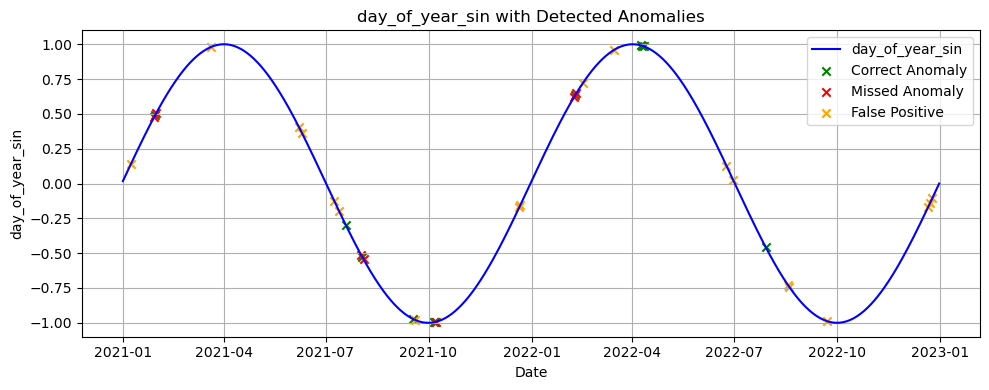

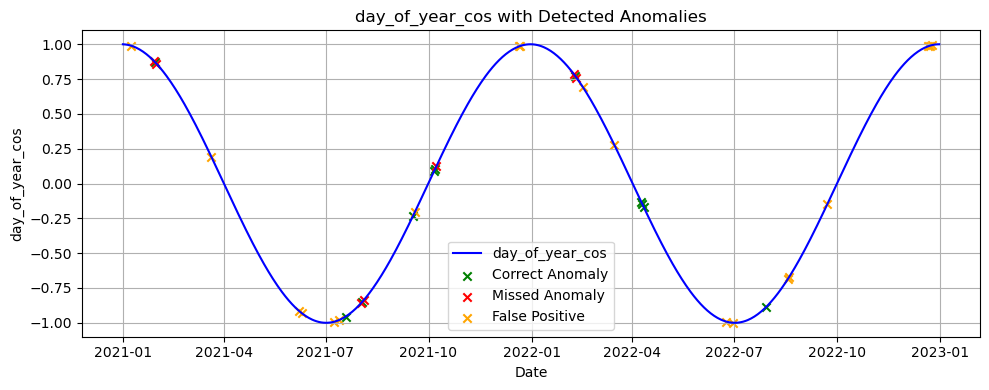

In [18]:
from sklearn.neighbors import LocalOutlierFactor

contamination = 0.04
n_neighbours = 6

dflof = dropColumns(df2122Transformed)
local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours, contamination=contamination)
lof_labels = local_outlier_factor.fit_predict(dflof)
lof_table = start_table()
evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"({contamination},{n_neighbours})", header=False, table=lof_table)
lof_table.report()

plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="season_encoded_cos")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="season_encoded_sin")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="humidity")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="year")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="day_of_year_sin")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="day_of_year_cos")

Plotting every feature against the detected anomalies, _humidity_ is a very noisy feature. _Humidity_ is responsible for several of the false positives. The true anomalies were reflected in both _energy_usage_ and _temperature_. _Year_ also provides little information.

The anomalies that were missed were during transitions to an extreme value. If the transitional value was close to the previous values, it wouldn't be considered extreme enough. By dropping _year_, the anomaly at 2022-07 becomes close enough to 2021-07 to be considered normal.

False positives were also found during sharp transitions, where values are rapidly changing between states, such as 2021-04.

The anomalies in the dataset are all contextual, taking place over multiple days. There may be a single point anomaly at ~2022-07, but the value it returns is similar to the normal temperature range.

## e) (AIML420 mandatory)  Exploring Alternative Approaches

### Improved Pre-processing

With this work, I will be looking to improve both LOF and ISO solutions. The above solutions didn't invoke the "train/evaluate/train" loop, using the default features with no real analysis.

For LOF, drop the columns identified in the analysis, year and humidity. Additionally, drop the encoded season since it doesn't have an impact either way.

For ISO, again drop year and humidity. Then explore what happens when day_of_year is removed, and sin/cos encoded season is kept. Test what happens when day_of_year is bucketed into day_of_week and week_of_year, with both sin/cos encoded. Bucket temperature, testing both equal size and equal temperature.

Finally for ISO, try bootstrapping and modifying the other parameters (feature subsampling, num_samples), to see what happens. Bootstrapping may improve results in the tree, and feature subsampling may help the trees find the right features to use.

For ensemble, create weaker models for both Isolation Forest and Local Outlier Factor which have high recall. Then see if the intersection of the results produces a better result - hopefully the errors are independent.



#### Local Outlier Factor Improved Pre-Processing

In [19]:
from sklearn.neighbors import LocalOutlierFactor

dflof = dropColumns(df2122Transformed,  columns = DEFAULT_COLUMNS_TO_DROP + ['humidity', 'year', 'season_encoded_sin', 'season_encoded_cos'])

lofHyperParameterStep1(dflof)

lofHyperParameterStep2(
    dataframe=dflof,
    contamination_list=(0.05, 0.01, 0.015, 0.02, 0.03, 0.04),
    n_neighbours_list=(5,6,7,8,9,10))


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| c=0.03 | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| c=0.035 | 0.556 | 0.385 | 0.455 | 10 | 8 | 16 |
| c=0.04 | 0.556 | 0.333 | 0.417 | 10 | 8 | 20 |
| c=0.045 | 0.556 | 0.303 | 0.392 | 10 | 8 | 23 |
| c=0.05 | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| c=0.0739 | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| c=0.08 | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| c=0.1 | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| c=0.15 | 0.778 | 0.127 | 0.219 | 14 | 4 | 96 |
| c=0.2 | 0.833 | 0.103 | 0.183 | 15 | 3 | 131 |
| c=0.25 | 0.833 | 0.082 | 0.149 | 15 | 3 | 168 |
| c=0.3 | 0.889 | 0.073 | 0.135 | 16 | 2 | 203 |
| c=0.35 | 1.000 | 0.070 | 0.131 | 18 | 0 | 238 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 0.556 | 0.312 | 0.400 | 10 | 8 | 22 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=2 | 0.778 | 0.152 | 0.255 | 14 | 4 | 78 |
| n=3 | 0.722 | 0.255 | 0.377 | 13 | 5 | 38 |
| n=4 | 0.722 | 0.289 | 0.413 | 13 | 5 | 32 |
| n=5 | 0.722 | 0.333 | 0.456 | 13 | 5 | 26 |
| n=6 | 0.722 | 0.406 | 0.520 | 13 | 5 | 19 |
| n=7 | 0.722 | 0.481 | 0.578 | 13 | 5 | 14 |
| n=10 | 0.667 | 0.500 | 0.571 | 12 | 6 | 12 |
| n=20 | 0.556 | 0.312 | 0.400 | 10 | 8 | 22 |
| n=30 | 0.556 | 0.256 | 0.351 | 10 | 8 | 29 |
| n=40 | 0.500 | 0.200 | 0.286 | 9 | 9 | 36 |
| n=50 | 0.667 | 0.190 | 0.296 | 12 | 6 | 51 |
| n=60 | 0.667 | 0.156 | 0.253 | 12 | 6 | 65 |
| n=70 | 0.667 | 0.146 | 0.240 | 12 | 6 | 70 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.05,5) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05,6) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05,7) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05,8) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05,9) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05,10) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.01,5) | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| (0.01,6) | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| (0.01,7) | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| (0.01,8) | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| (0.01,9) | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| (0.01,10) | 0.389 | 0.875 | 0.538 | 7 | 11 | 1 |
| (0.015,5) | 0.444 | 0.727 | 0.552 | 8 | 10 | 3 |
| (0.015,6) | 0.444 | 0.727 | 0.552 | 8 | 10 | 3 |
| (0.015,7) | 0.500 | 0.818 | 0.621 | 9 | 9 | 2 |
| (0.015,8) | 0.500 | 0.818 | 0.621 | 9 | 9 | 2 |
| (0.015,9) | 0.500 | 0.818 | 0.621 | 9 | 9 | 2 |
| (0.015,10) | 0.500 | 0.818 | 0.621 | 9 | 9 | 2 |
| (0.02,5) | 0.611 | 0.733 | 0.667 | 11 | 7 | 4 |
| (0.02,6) | 0.611 | 0.733 | 0.667 | 11 | 7 | 4 |
| (0.02,7) | 0.611 | 0.733 | 0.667 | 11 | 7 | 4 |
| (0.02,8) | 0.667 | 0.800 | 0.727 | 12 | 6 | 3 |
| (0.02,9) | 0.667 | 0.800 | 0.727 | 12 | 6 | 3 |
| (0.02,10) | 0.667 | 0.800 | 0.727 | 12 | 6 | 3 |
| (0.03,5) | 0.722 | 0.591 | 0.650 | 13 | 5 | 9 |
| (0.03,6) | 0.667 | 0.545 | 0.600 | 12 | 6 | 10 |
| (0.03,7) | 0.667 | 0.545 | 0.600 | 12 | 6 | 10 |
| (0.03,8) | 0.667 | 0.545 | 0.600 | 12 | 6 | 10 |
| (0.03,9) | 0.667 | 0.545 | 0.600 | 12 | 6 | 10 |
| (0.03,10) | 0.667 | 0.545 | 0.600 | 12 | 6 | 10 |
| (0.04,5) | 0.722 | 0.433 | 0.542 | 13 | 5 | 17 |
| (0.04,6) | 0.722 | 0.433 | 0.542 | 13 | 5 | 17 |
| (0.04,7) | 0.722 | 0.433 | 0.542 | 13 | 5 | 17 |
| (0.04,8) | 0.722 | 0.433 | 0.542 | 13 | 5 | 17 |
| (0.04,9) | 0.722 | 0.433 | 0.542 | 13 | 5 | 17 |
| (0.04,10) | 0.722 | 0.433 | 0.542 | 13 | 5 | 17 |


#### Local Outlier Factor Results

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.02,8) | 0.667 | 0.800 | 0.727 | 12 | 6 | 3 |


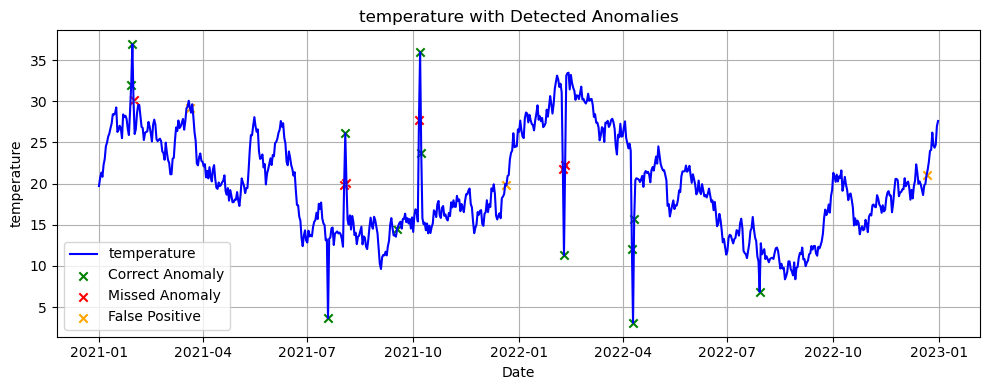

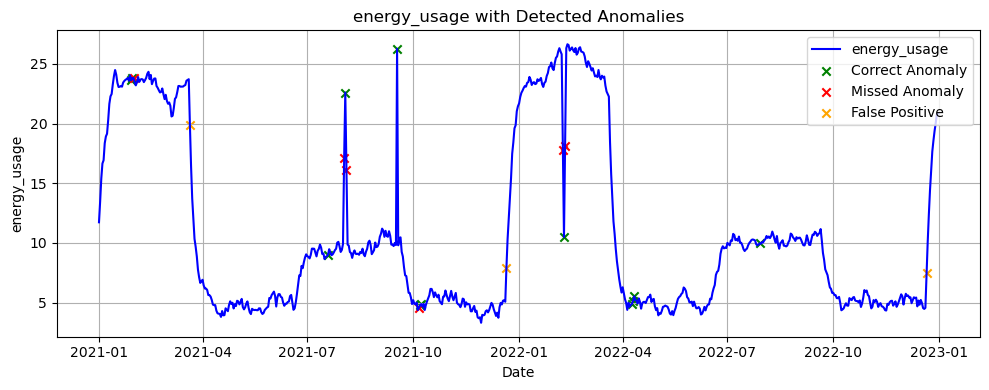

In [20]:
contamination = 0.02
n_neighbours = 8

dflof = dropColumns(df2122Transformed,  columns = DEFAULT_COLUMNS_TO_DROP + ['humidity', 'year', 'season_encoded_sin', 'season_encoded_cos'])
# 'season_encoded_sin', 'season_encoded_cos' have no impact either way.
local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours, contamination=contamination)
lof_labels = local_outlier_factor.fit_predict(dflof)
lof_table = start_table()
evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"({contamination},{n_neighbours})", header=False, table=lof_table)
lof_table.report()

plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")

When we started, we had {correct, Missed, False Positives} = {11, 7, 19}. After tuning, we now have {12, 6, 3}.

The reduction in false positives was dramatic. Looking at the anomalies that were missed, we can see that it is typically on the way up to the maximum anomaly, or on the way back down from the anomaly. This gives us a time-to-detect bound of 48 hours (detect on 2nd day), which may be acceptable.

#### Isolation Forest Improved Pre-Processing

Dropping year, humidity and day_of_year showed some improvements at phase 1, but not enough. "auto" did have 1/2 the false positives in return for 1 missed anomaly.

* c=0.01 - 3,15,5
* c=auto - 17,1,154

* n=5 - 14,4,219
* n=500 - 17,1,158

1. drop year and humidity
2. drop day_of_year - signal is in season.

3. bucket temperature

Bucketing temperature was finicky, and depended on the number of buckets. 10 bins worked best with {0.03, 400} --> 11, 7, 11 --> 0.550 . It still has too many false positives, with precision = 0.5.

Equal frequency with decile buckets performed slightlye worse than equal range buckets. Quartile buckets performed the same as 10 equal range bins.

Bucketing energy_usage decreased performance using either equal frequency or equal range.

Transforming Day_of_Year to Day_Of_Week and Week_Of_Year reduced performance over bucketing.


In [32]:
dfiso = dropColumns(df2122Transformed,
                    columns = DEFAULT_COLUMNS_TO_DROP + ['humidity', 'year', 'day_of_year_sin', 'day_of_year_cos'])

# day_of_year bucketing
# Temperature Bucketing.
# Energy use bucketing.
dfiso['temperature_binned'] = pd.cut(
    dfiso['temperature'], bins=10, labels=False)
# dfiso['temperature_binned'] = pd.qcut(
#     dfiso['temperature'], q=25, labels=False)
dfiso.drop(columns=['temperature'])

# dfiso['energy_usage_binned'] = pd.cut(
#     dfiso['energy_usage'], bins=15, labels=False)
# dfiso['energy_usage_binned'] = pd.qcut(
#     dfiso['energy_usage'], q=25, labels=False)

dfiso.drop(columns=['energy_usage'])


isoTableHyperParameterStep1(dfiso)

isoTableHyperParameterStep2(
    dataframe=dfiso,
    contamination_list=(0.01, 0.03, 0.05, 0.07, 0.0739, 0.08, 0.09, 0.1, 0.15, 0.2),
    n_neighbours_list=(5, 50, 100, 200, 250, 300, 350, 400, 500))

# 0.03, 400, 11, 7, 11 0.550

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| c=0.03 | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| c=0.05 | 0.667 | 0.324 | 0.436 | 12 | 6 | 25 |
| c=0.0739 | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| c=0.08 | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| c=0.1 | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| c=0.15 | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| c=0.2 | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| c=0.25 | 0.944 | 0.093 | 0.169 | 17 | 1 | 166 |
| c=0.3 | 1.000 | 0.082 | 0.152 | 18 | 0 | 201 |
| c=0.35 | 1.000 | 0.070 | 0.131 | 18 | 0 | 238 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 1.000 | 0.094 | 0.172 | 18 | 0 | 173 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=5 | 0.944 | 0.074 | 0.137 | 17 | 1 | 213 |
| n=10 | 0.944 | 0.085 | 0.155 | 17 | 1 | 184 |
| n=30 | 0.944 | 0.091 | 0.167 | 17 | 1 | 169 |
| n=50 | 0.944 | 0.091 | 0.167 | 17 | 1 | 169 |
| n=100 | 1.000 | 0.094 | 0.172 | 18 | 0 | 173 |
| n=200 | 0.944 | 0.102 | 0.184 | 17 | 1 | 150 |
| n=300 | 0.944 | 0.105 | 0.189 | 17 | 1 | 145 |
| n=400 | 0.944 | 0.098 | 0.177 | 17 | 1 | 157 |
| n=500 | 0.944 | 0.099 | 0.180 | 17 | 1 | 154 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.01, 5) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 50) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 100) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01, 200) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 250) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 300) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 350) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01, 400) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01, 500) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.03, 5) | 0.389 | 0.333 | 0.359 | 7 | 11 | 14 |
| (0.03, 50) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03, 100) | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| (0.03, 200) | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| (0.03, 250) | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| (0.03, 300) | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| (0.03, 350) | 0.611 | 0.500 | 0.550 | 11 | 7 | 11 |
| (0.03, 400) | 0.611 | 0.500 | 0.550 | 11 | 7 | 11 |
| (0.03, 500) | 0.611 | 0.500 | 0.550 | 11 | 7 | 11 |
| (0.05, 5) | 0.667 | 0.324 | 0.436 | 12 | 6 | 25 |
| (0.05, 50) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 100) | 0.667 | 0.324 | 0.436 | 12 | 6 | 25 |
| (0.05, 200) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 250) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 300) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 350) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 400) | 0.778 | 0.378 | 0.509 | 14 | 4 | 23 |
| (0.05, 500) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.07, 5) | 0.722 | 0.250 | 0.371 | 13 | 5 | 39 |
| (0.07, 50) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 100) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 200) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 250) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 300) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 350) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 400) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 500) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.0739, 5) | 0.722 | 0.250 | 0.371 | 13 | 5 | 39 |
| (0.0739, 50) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 100) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 200) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 250) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 300) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 350) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 400) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 500) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.08, 5) | 0.722 | 0.224 | 0.342 | 13 | 5 | 45 |
| (0.08, 50) | 0.833 | 0.254 | 0.390 | 15 | 3 | 44 |
| (0.08, 100) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 200) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 250) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 300) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 350) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 400) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 500) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.09, 5) | 0.722 | 0.200 | 0.313 | 13 | 5 | 52 |
| (0.09, 50) | 0.833 | 0.227 | 0.357 | 15 | 3 | 51 |
| (0.09, 100) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 200) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 250) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 300) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 350) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 400) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 500) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.1, 5) | 0.722 | 0.183 | 0.292 | 13 | 5 | 58 |
| (0.1, 50) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 100) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 200) | 0.778 | 0.192 | 0.308 | 14 | 4 | 59 |
| (0.1, 250) | 0.778 | 0.192 | 0.308 | 14 | 4 | 59 |
| (0.1, 300) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 350) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 400) | 0.778 | 0.192 | 0.308 | 14 | 4 | 59 |
| (0.1, 500) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.15, 5) | 0.722 | 0.118 | 0.203 | 13 | 5 | 97 |
| (0.15, 50) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.15, 100) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 200) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 250) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 300) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 350) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 400) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 500) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.2, 5) | 0.778 | 0.096 | 0.171 | 14 | 4 | 132 |
| (0.2, 50) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 100) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 200) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 250) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 300) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 350) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 400) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 500) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |


In [112]:
from datetime import datetime, timedelta

def toDoW(year, day_of_year):
    date = datetime(year, 1, 1) + timedelta(day_of_year - 1)
    return date.isocalendar().weekday

def toWeek(year, day_of_year):
    date = datetime(year, 1, 1) + timedelta(day_of_year - 1)
    return date.isocalendar().week

# Add back day_of_year via bucketing by day_of_week and week_of_year.

dfcopy = df2122Transformed.copy()
dfcopy['day_of_week'] = dfcopy.apply(lambda row: toDoW(row['year'], row['day_of_year']), axis=1)
dfcopy['week_of_year'] = dfcopy.apply(lambda row: toWeek(row['year'], row['day_of_year']), axis=1)

sin_cos_transform('day_of_week', dfcopy)
sin_cos_transform('week_of_year', dfcopy)
dfcopy.drop(columns=['day_of_week', 'week_of_year'], inplace=True)

dfiso = dropColumns(dfcopy,
                    columns = DEFAULT_COLUMNS_TO_DROP + ['humidity', 'year', 'day_of_year_sin', 'day_of_year_cos', 'season_encoded_sin', 'season_encoded_cos'])

dfiso['temperature_binned'] = pd.cut(
    dfiso['temperature'], bins=10, labels=False)

dfiso.drop(columns=('temperature'))

isoTableHyperParameterStep1(dfiso)

isoTableHyperParameterStep2(
    dataframe=dfiso,
    contamination_list=(0.01, 0.03, 0.05, 0.07, 0.0739, 0.08, 0.09, 0.1, 0.15, 0.2),
    n_neighbours_list=(5, 50, 100, 200, 250, 300, 350, 400, 500))

# 0.03, 300 8, 10, 14, 0.400

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| c=0.03 | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| c=0.05 | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| c=0.0739 | 0.556 | 0.185 | 0.278 | 10 | 8 | 44 |
| c=0.08 | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| c=0.1 | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| c=0.15 | 0.833 | 0.136 | 0.234 | 15 | 3 | 95 |
| c=0.2 | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| c=0.25 | 0.944 | 0.093 | 0.169 | 17 | 1 | 166 |
| c=0.3 | 0.944 | 0.078 | 0.143 | 17 | 1 | 202 |
| c=0.35 | 1.000 | 0.070 | 0.131 | 18 | 0 | 238 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 1.000 | 0.046 | 0.088 | 18 | 0 | 372 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=5 | 0.611 | 0.038 | 0.071 | 11 | 7 | 282 |
| n=10 | 0.889 | 0.062 | 0.115 | 16 | 2 | 244 |
| n=30 | 1.000 | 0.050 | 0.096 | 18 | 0 | 340 |
| n=50 | 1.000 | 0.047 | 0.091 | 18 | 0 | 361 |
| n=100 | 1.000 | 0.046 | 0.088 | 18 | 0 | 372 |
| n=200 | 1.000 | 0.040 | 0.077 | 18 | 0 | 429 |
| n=300 | 1.000 | 0.039 | 0.075 | 18 | 0 | 444 |
| n=400 | 1.000 | 0.038 | 0.074 | 18 | 0 | 450 |
| n=500 | 1.000 | 0.039 | 0.075 | 18 | 0 | 446 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.01, 5) | 0.333 | 0.750 | 0.462 | 6 | 12 | 2 |
| (0.01, 50) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 100) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 200) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 250) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 300) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 350) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01, 400) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01, 500) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.03, 5) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 50) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 100) | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| (0.03, 200) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 250) | 0.389 | 0.318 | 0.350 | 7 | 11 | 15 |
| (0.03, 300) | 0.389 | 0.318 | 0.350 | 7 | 11 | 15 |
| (0.03, 350) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03, 400) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03, 500) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.05, 5) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 50) | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| (0.05, 100) | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| (0.05, 200) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05, 250) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05, 300) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05, 350) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05, 400) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05, 500) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.07, 5) | 0.444 | 0.154 | 0.229 | 8 | 10 | 44 |
| (0.07, 50) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 100) | 0.556 | 0.192 | 0.286 | 10 | 8 | 42 |
| (0.07, 200) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 250) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 300) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 350) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.07, 400) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.07, 500) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.0739, 5) | 0.444 | 0.151 | 0.225 | 8 | 10 | 45 |
| (0.0739, 50) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 100) | 0.556 | 0.185 | 0.278 | 10 | 8 | 44 |
| (0.0739, 200) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 250) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 300) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 350) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739, 400) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739, 500) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.08, 5) | 0.444 | 0.136 | 0.208 | 8 | 10 | 51 |
| (0.08, 50) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 100) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 200) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 250) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.08, 300) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.08, 350) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.08, 400) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.08, 500) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.09, 5) | 0.500 | 0.136 | 0.214 | 9 | 9 | 57 |
| (0.09, 50) | 0.611 | 0.167 | 0.262 | 11 | 7 | 55 |
| (0.09, 100) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.09, 200) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.09, 250) | 0.722 | 0.197 | 0.310 | 13 | 5 | 53 |
| (0.09, 300) | 0.722 | 0.197 | 0.310 | 13 | 5 | 53 |
| (0.09, 350) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 400) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 500) | 0.722 | 0.197 | 0.310 | 13 | 5 | 53 |
| (0.1, 5) | 0.500 | 0.123 | 0.198 | 9 | 9 | 64 |
| (0.1, 50) | 0.611 | 0.151 | 0.242 | 11 | 7 | 62 |
| (0.1, 100) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 200) | 0.778 | 0.192 | 0.308 | 14 | 4 | 59 |
| (0.1, 250) | 0.778 | 0.192 | 0.308 | 14 | 4 | 59 |
| (0.1, 300) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 350) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 400) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 500) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.15, 5) | 0.556 | 0.091 | 0.156 | 10 | 8 | 100 |
| (0.15, 50) | 0.778 | 0.127 | 0.219 | 14 | 4 | 96 |
| (0.15, 100) | 0.833 | 0.136 | 0.234 | 15 | 3 | 95 |
| (0.15, 200) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.15, 250) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.15, 300) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.15, 350) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.15, 400) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.15, 500) | 0.889 | 0.145 | 0.250 | 16 | 2 | 94 |
| (0.2, 5) | 0.556 | 0.069 | 0.123 | 10 | 8 | 134 |
| (0.2, 50) | 0.889 | 0.110 | 0.195 | 16 | 2 | 130 |
| (0.2, 100) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 200) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 250) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 300) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 350) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 400) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 500) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |


In [52]:
# Bootstrap - no improvement.
# single feature trees - terrible performance
# 50% feature trees - not very good either.

dfiso = dropColumns(df2122Transformed,
                    columns = DEFAULT_COLUMNS_TO_DROP + ['humidity', 'year', 'day_of_year_sin', 'day_of_year_cos'])
dfiso['temperature_binned'] = pd.cut(
    dfiso['temperature'], bins=10, labels=False)
dfiso.drop(columns=('temperature'))

isoTableHyperParameterStep1(dfiso, bootstrap=True)

isoTableHyperParameterStep2(
    bootstrap=True,
    dataframe=dfiso,
    contamination_list=(0.01, 0.03, 0.05, 0.07, 0.0739, 0.08, 0.09, 0.1, 0.15, 0.2),
    n_neighbours_list=(5, 50, 100, 200, 250, 300, 350, 400, 500))


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| c=0.03 | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| c=0.05 | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| c=0.0739 | 0.833 | 0.278 | 0.417 | 15 | 3 | 39 |
| c=0.08 | 0.889 | 0.271 | 0.416 | 16 | 2 | 43 |
| c=0.1 | 0.889 | 0.219 | 0.352 | 16 | 2 | 57 |
| c=0.15 | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| c=0.2 | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| c=0.25 | 0.944 | 0.093 | 0.169 | 17 | 1 | 166 |
| c=0.3 | 1.000 | 0.082 | 0.152 | 18 | 0 | 201 |
| c=0.35 | 1.000 | 0.070 | 0.131 | 18 | 0 | 238 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 1.000 | 0.076 | 0.142 | 18 | 0 | 218 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=5 | 0.889 | 0.065 | 0.122 | 16 | 2 | 229 |
| n=10 | 1.000 | 0.077 | 0.143 | 18 | 0 | 215 |
| n=30 | 1.000 | 0.075 | 0.139 | 18 | 0 | 223 |
| n=50 | 1.000 | 0.076 | 0.141 | 18 | 0 | 220 |
| n=100 | 1.000 | 0.076 | 0.142 | 18 | 0 | 218 |
| n=200 | 1.000 | 0.080 | 0.149 | 18 | 0 | 206 |
| n=300 | 1.000 | 0.077 | 0.143 | 18 | 0 | 215 |
| n=400 | 1.000 | 0.076 | 0.141 | 18 | 0 | 219 |
| n=500 | 1.000 | 0.076 | 0.141 | 18 | 0 | 219 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.01, 5) | 0.333 | 0.857 | 0.480 | 6 | 12 | 1 |
| (0.01, 50) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 100) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 200) | 0.278 | 0.625 | 0.385 | 5 | 13 | 3 |
| (0.01, 250) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 300) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 350) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 400) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 500) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.03, 5) | 0.389 | 0.318 | 0.350 | 7 | 11 | 15 |
| (0.03, 50) | 0.389 | 0.318 | 0.350 | 7 | 11 | 15 |
| (0.03, 100) | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| (0.03, 200) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03, 250) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03, 300) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03, 350) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03, 400) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.03, 500) | 0.500 | 0.409 | 0.450 | 9 | 9 | 13 |
| (0.05, 5) | 0.444 | 0.216 | 0.291 | 8 | 10 | 29 |
| (0.05, 50) | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| (0.05, 100) | 0.556 | 0.270 | 0.364 | 10 | 8 | 27 |
| (0.05, 200) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 250) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 300) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 350) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 400) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.05, 500) | 0.722 | 0.351 | 0.473 | 13 | 5 | 24 |
| (0.07, 5) | 0.556 | 0.192 | 0.286 | 10 | 8 | 42 |
| (0.07, 50) | 0.833 | 0.288 | 0.429 | 15 | 3 | 37 |
| (0.07, 100) | 0.833 | 0.288 | 0.429 | 15 | 3 | 37 |
| (0.07, 200) | 0.889 | 0.308 | 0.457 | 16 | 2 | 36 |
| (0.07, 250) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 300) | 0.833 | 0.288 | 0.429 | 15 | 3 | 37 |
| (0.07, 350) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 400) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.07, 500) | 0.778 | 0.269 | 0.400 | 14 | 4 | 38 |
| (0.0739, 5) | 0.556 | 0.189 | 0.282 | 10 | 8 | 43 |
| (0.0739, 50) | 0.833 | 0.278 | 0.417 | 15 | 3 | 39 |
| (0.0739, 100) | 0.833 | 0.278 | 0.417 | 15 | 3 | 39 |
| (0.0739, 200) | 0.889 | 0.296 | 0.444 | 16 | 2 | 38 |
| (0.0739, 250) | 0.833 | 0.278 | 0.417 | 15 | 3 | 39 |
| (0.0739, 300) | 0.833 | 0.278 | 0.417 | 15 | 3 | 39 |
| (0.0739, 350) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 400) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.0739, 500) | 0.778 | 0.259 | 0.389 | 14 | 4 | 40 |
| (0.08, 5) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 50) | 0.889 | 0.271 | 0.416 | 16 | 2 | 43 |
| (0.08, 100) | 0.889 | 0.271 | 0.416 | 16 | 2 | 43 |
| (0.08, 200) | 0.889 | 0.271 | 0.416 | 16 | 2 | 43 |
| (0.08, 250) | 0.889 | 0.271 | 0.416 | 16 | 2 | 43 |
| (0.08, 300) | 0.833 | 0.254 | 0.390 | 15 | 3 | 44 |
| (0.08, 350) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 400) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.08, 500) | 0.778 | 0.237 | 0.364 | 14 | 4 | 45 |
| (0.09, 5) | 0.667 | 0.190 | 0.296 | 12 | 6 | 51 |
| (0.09, 50) | 0.889 | 0.242 | 0.381 | 16 | 2 | 50 |
| (0.09, 100) | 0.889 | 0.242 | 0.381 | 16 | 2 | 50 |
| (0.09, 200) | 0.889 | 0.242 | 0.381 | 16 | 2 | 50 |
| (0.09, 250) | 0.889 | 0.242 | 0.381 | 16 | 2 | 50 |
| (0.09, 300) | 0.889 | 0.242 | 0.381 | 16 | 2 | 50 |
| (0.09, 350) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 400) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.09, 500) | 0.778 | 0.212 | 0.333 | 14 | 4 | 52 |
| (0.1, 5) | 0.722 | 0.178 | 0.286 | 13 | 5 | 60 |
| (0.1, 50) | 0.889 | 0.219 | 0.352 | 16 | 2 | 57 |
| (0.1, 100) | 0.889 | 0.219 | 0.352 | 16 | 2 | 57 |
| (0.1, 200) | 0.889 | 0.219 | 0.352 | 16 | 2 | 57 |
| (0.1, 250) | 0.889 | 0.219 | 0.352 | 16 | 2 | 57 |
| (0.1, 300) | 0.889 | 0.219 | 0.352 | 16 | 2 | 57 |
| (0.1, 350) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.1, 400) | 0.778 | 0.192 | 0.308 | 14 | 4 | 59 |
| (0.1, 500) | 0.833 | 0.205 | 0.330 | 15 | 3 | 58 |
| (0.15, 5) | 0.833 | 0.138 | 0.236 | 15 | 3 | 94 |
| (0.15, 50) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 100) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 200) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 250) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 300) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 350) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 400) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.15, 500) | 0.944 | 0.155 | 0.266 | 17 | 1 | 93 |
| (0.2, 5) | 0.833 | 0.103 | 0.183 | 15 | 3 | 131 |
| (0.2, 50) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 100) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 200) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 250) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 300) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 350) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 400) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |
| (0.2, 500) | 0.944 | 0.116 | 0.207 | 17 | 1 | 129 |


##### Isolation Forest Results

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.03, 400) | 0.611 | 0.500 | 0.550 | 11 | 7 | 11 |


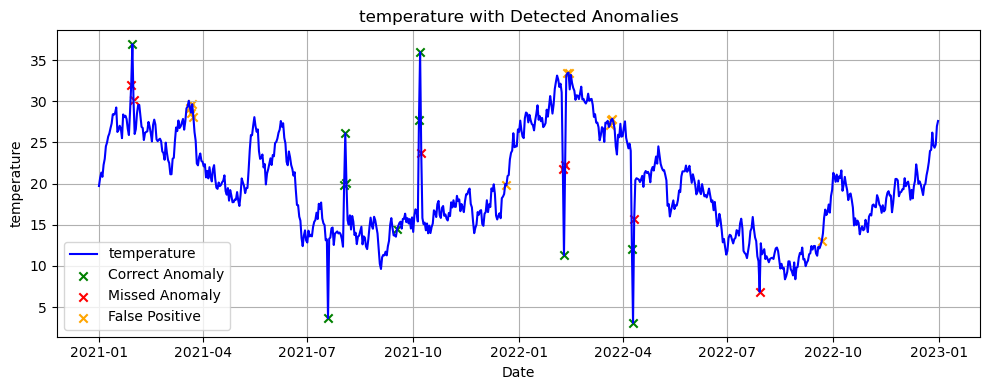

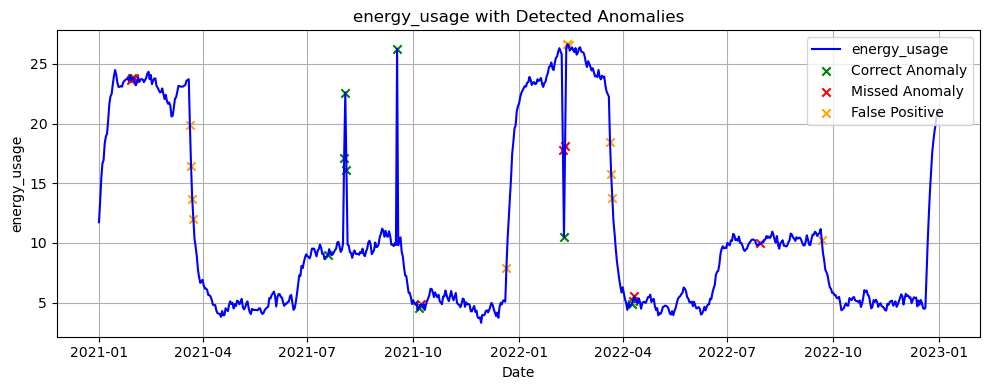

In [114]:
contamination = 0.03
n_neighbours = 400

dfiso = dropColumns(df2122Transformed,
                    columns = DEFAULT_COLUMNS_TO_DROP + ['humidity', 'year', 'day_of_year_sin', 'day_of_year_cos'])
dfiso['temperature_binned'] = pd.cut(
    dfiso['temperature'], bins=10, labels=False)
dfiso.drop(columns=('temperature'))

iso_table = start_table()
isolation_forest = IsolationForest(random_state=random_seed, contamination=contamination, n_estimators=n_estimators)
if_labels = isolation_forest.fit_predict(dfiso)
evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"({contamination}, {n_estimators})", header=False, table=iso_table)

iso_table.report()

plot_detection(df=df2122Transformed, y_true=y2122, y_pred=if_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df2122Transformed, y_true=y2122, y_pred=if_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")



### Ensemble

See if the improved dataset helps with the Isolation Trees, and combine them into an ensemble.



In [ ]:
# Find a weak LoF model
# Find a weak ISO Forest model (they all are)
# Intersect the Y's, looking for values in both.